## About the Notebook:

This analysis explores spatial and environmental factors associated with river water quality. Satellite imagery from climate variables, such as Potential Evapotranspiration (PET) were incorporated to provide broader environmental context around observed water quality conditions and reflect underlying climatic influences. The analysis focuses on data collected between 2011 and 2015. Relevant satellite and climate features were retrieved using API-based access through the Microsoft Planetary Computer portal and combined with water quality observations. Together, these datasets support an exploratory assessment of three key water quality parameters. 

In this notebook, I'll explore how measurements of Potential Evapotranspiration (PET), Electrical Conductance (EC) and Total Alkalinity (TA) are distributed spatially across South Africa.

### **Load Dependencies**

```%pip install geopandas folium seaborn watermark```

In [4]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import MultiPolygon
import folium
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

sns.set_theme()

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

%load_ext watermark
%watermark -v
%watermark --iversions

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.11.9
IPython version      : 9.8.0

contextily: 1.7.0
folium    : 0.20.0
geopandas : 1.1.2
matplotlib: 3.10.8
numpy     : 2.4.0
pandas    : 2.3.3
seaborn   : 0.13.2
shapely   : 2.1.2



#### **Define functions**

In [5]:
def spatial_plot_PET(provinces, gdf, var1='geometry', var2='province', var3='pet',var4='pop_density_nn',
                     title='Potential Evapotranspiration at Sampling Locations', legend_kwds={'label':'PET (mm/day)'}):
    '''
    Plots Chloropleth
    input
    -----
    - df: geopandas dataframe
    - var1: str
    - var2: str
    - var3: str
    - var4: str
    - title: str
    - legend_kwds: dict
    
    return
    ------
    Cloropleth
    '''
    # Plot
    fig, ax = plt.subplots(figsize=(11, 7))
    
    # Province Map
    provinces.plot(ax=ax, color='#B6B6B6')
    provinces['coords'] = provinces[var1].apply(lambda x: x.representative_point().coords[:])
    provinces['coords'] = [coords[0] for coords in provinces['coords']]
    for idx, row in provinces.iterrows():
        plt.annotate(text=row[var2], xy=row['coords'], horizontalalignment='center', color='white')
    #https://medium.com/nerd-for-tech/labelling-areas-of-coordinates-with-geopandas-74d25c8aada6
    
    # Overlay PET Data
    gdf.plot(column=var3, ax=ax, marker='o', markersize=gdf[var4], cmap='Blues', vmin=0, legend=True, legend_kwds=legend_kwds) #
    
    # ax.set_axis_off() # leave the axis to see correlation between position and PET value
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show();


def spatial_plot_AT_EC(df, gdf, col1:str='electrical conductance', col2:str='total alkalinity', var:str='pop_density_nn', plot_unideal=False,
                       title:str='Population Density, TA and EC at Sampling Locations', legend_kwds1=dict, legend_kwds2=dict):
    '''
    Layer scatter plot onto chloropleth map with legends and preattentive attributes
    input
    -----
    - df: geopandas dataframe
    - col1: str
    - col2: str
    - var1: str
    - plot_unideal: bool
    - title: str
    - legend_kwds1: dict
    - legend_kwds2: dict
    
    return
    ------
    GeoPandas Plot
    '''

    fig, ax = plt.subplots(figsize=(11, 7))
    
    # Set up color map
    cmap1 = LinearSegmentedColormap.from_list("mycmap", ['#B6B6B6','#DB7629'])
    cmap2 = LinearSegmentedColormap.from_list("mycmap", ['#B6B6B6','#0E86E0'])
    
    df.plot(column=col1, ax=ax, zorder=1, cmap=cmap1, alpha=0.6, vmin=0, legend=True, legend_kwds=legend_kwds1)
    gdf.plot(column=col2, ax=ax, marker='o', markersize=gdf[var], cmap=cmap2, vmin=0, legend=True, legend_kwds=legend_kwds2)
    
    if plot_unideal == True:
        unideal_wq.plot(column='unideal', ax=ax, marker='^', markersize=100, color='red')
    else:
        pass

    ax.set_axis_off()
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show();



def piv(df, x='province', y='pet', by='province'):
    '''
    input
    -----
    x: str; column name of pandas dataframe
    y: str; column name of pandas dataframe

    returns
    -------
    pandas dataframe pivot grouped by x and values sorted by y
    '''
    df = df[[x, y]].groupby(x).mean().sort_values(by=by, ascending=True)
    df = df[y].round().astype(int)
    return df.reset_index();


def bar_horizontal(df, x='province', y='pet', title=str):
    '''
    input
    -----
    x: str; column name of pandas dataframe
    y: str; column name of pandas dataframe

    returns
    -------
    matplotlib horizontal bar plot
    '''
    fig, ax = plt.subplots(figsize=(12, 5))
    plt.barh(df[x], df[y].round().astype(int), xerr=None, color='#0E86E0')
    ax.set_xticklabels(labels=df[y])
    plt.get_cmap('viridis')
    plt.title(title);



#### **Load Data**

- Final dataset from pickle format including feature engineered ideal water quality attributes
- Shapefile for information on province geometry in South Africa

All the data will be read into GeoDataFrames, which have columns for geographic location and areas. This is useful for plotting maps.

https://simplemaps.com/gis/country/za --> download shapefile  
https://simplemaps.com/static/svg/country/za/admin1/za_shp.zip

In [6]:
df = pd.read_pickle('data/ideal_vs_unideal.pkl')
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)
print('Variables we can work with:',list(gdf.columns))

# isolate all sample locations with "unideal" water quality into a separate dataframe
unideal_wq = gdf[gdf['unideal']==1]
print('There are',len(unideal_wq),'datapoints representing unideal water quality.')

path_to_data = 'data/za_shp'
provinces = gpd.read_file(path_to_data, layer='za').to_crs("EPSG:4326")
provinces = provinces.rename(columns={'name':'province'}).sort_values(by='province')

Variables we can work with:

 ['province', 'country', 'latitude', 'longitude', 'sample date', 'nir', 'green', 'swir16', 'swir22', 'ndmi', 'mndwi', 'pet', 'total alkalinity', 'electrical conductance', 'dissolved reactive phosphorus', 'month', 'sample_year', 'pop_density_nn', 'distance_km_to_pd_cell', 'river_mouthORjunction', 'river_mouth', 'river_junction', 'DRP', 'EC', 'Alkalinity', 'how_good', 'ideal', 'unideal', 'geometry']
There are 220 datapoints representing unideal water quality.


I broke down and had to ask AI how to do the next step <a href="https://search.brave.com/ask?q=poly+geometry+column+attributes+geopandas&source=quick-answer-followup&quickAnswerKey=08b6a94cb59b797c37ab73c2288ac22f4a90&quickAnswerQuery=poly+geometry+column+attributes+geopandas&conversation=08b68984eb40a57f229ccbefc071d17a3b3c">here</a>, and promted it as such, "how to convert a multipolygon geometry into a polygon geopandas".

In [7]:
# replace the Western Cape with just the main land, without PRINCE EDWARDS ISLANDS
new_polygon = provinces['geometry'].explode()[7][:1]
multipolygon = MultiPolygon(new_polygon)
provinces.loc[7, 'geometry'] = multipolygon
provinces

,id,province,source,geometry
3,ZAEC,Eastern Cape,https://simplemaps.com,"POLYGON ((24.14703 -31.78989, 24.15432 -31.758..."
2,ZAFS,Free State,https://simplemaps.com,"POLYGON ((25.46747 -30.61312, 25.43161 -30.592..."
8,ZAGP,Gauteng,https://simplemaps.com,"POLYGON ((28.25583 -26.8936, 28.24466 -26.8940..."
1,ZAKZN,KwaZulu-Natal,https://simplemaps.com,"POLYGON ((30.19597 -31.07789, 30.1925 -31.0729..."
4,ZALP,Limpopo,https://simplemaps.com,"POLYGON ((31.85649 -23.96296, 31.85623 -23.963..."
6,ZAMP,Mpumalanga,https://simplemaps.com,"POLYGON ((31.24471 -27.23259, 31.18764 -27.297..."
5,ZANW,North West,https://simplemaps.com,"POLYGON ((25.01349 -28.06821, 25.00512 -28.070..."
0,ZANC,Northern Cape,https://simplemaps.com,"POLYGON ((22.63695 -26.11428, 22.70516 -26.129..."
7,ZAWC,Western Cape,https://simplemaps.com,"MULTIPOLYGON (((17.76711 -31.15581, 17.76742 -..."


### Grouping water quality parameters by province and aggregate by mean

Evapotranspiration is the *combined* process of how moisture is transferred from the land level into the atmosphere.
This metric is often related to weather, climate & **water availability**.
- evaporation: water from the Earth's surface
- transpiration: water vapor from plants

Potential Evapotranspiration measurements may reflect temperature, humidity and vegetation type in any given region, measured in mm/day.  

https://en.wikipedia.org/wiki/Potential_evapotranspiration  
https://planetarycomputer.microsoft.com/dataset/terraclimate#overview

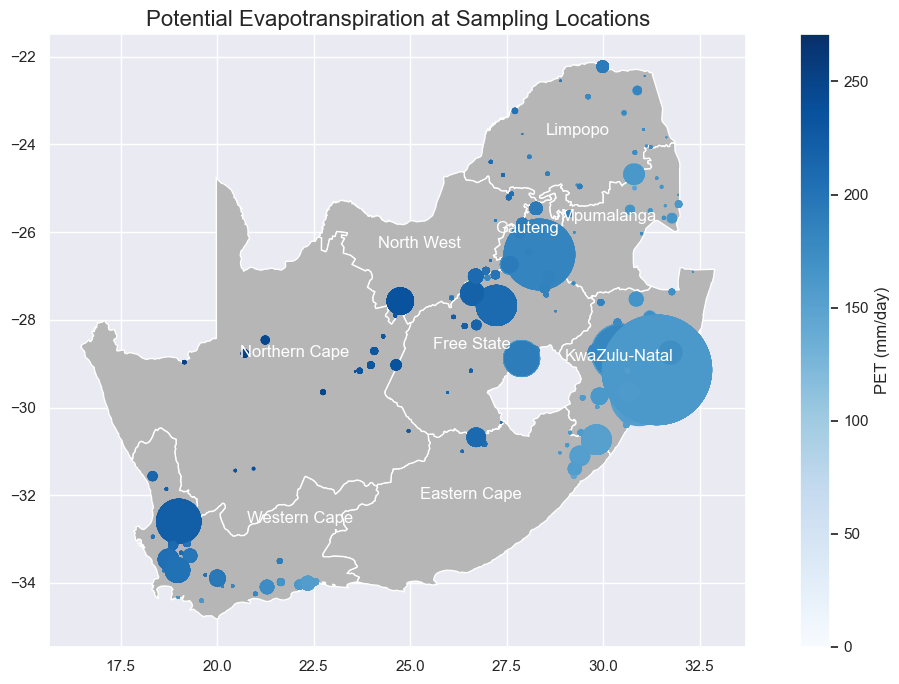

In [8]:
spatial_plot_PET(provinces, gdf, var1='geometry', var2='province', var3='pet',var4='pop_density_nn', title='Potential Evapotranspiration at Sampling Locations', legend_kwds={'label':'PET (mm/day)'})

In [9]:
round(pd.DataFrame(df['pet'].describe()), None).astype(int)

,pet
count,9093
mean,175
std,29
min,53
25%,156
50%,172
75%,193
max,271


### Observation and Analysis

PET values are encoded using color. The higher the PET value, the lighter the color becomes. It seems like PET value increases from east to west.

Potential Evapotranspiration is usually measured indirectly using other climactic factors, like the amount of Water Volume Evapotranspired from a sample location (mm day<sup>−1</sup>) during a specific time period. PET is dependent on temperature and vapor pressure. As the global temperature increases PET and humidity increase with it.  
Relative humidity could be merged with our dataset in the future for verification of this insight.

According to the snapshot below, the green areas representing more vegetative regions are mirroring the lower (darker) PET values above. This suggests that in areas with more vegetation, and possibly more humidity, water is less likely to transpire or evaporate. Further west, PET values are higher, which indicates a higher chance of transpiration/evaporation. Not surprisingly, the map below shows less vegetation in those same areas of the spatial plot.


https://en.wikipedia.org/wiki/Potential_evapotranspiration

![South Africa Google Maps](data/SouthAfrica_GoogleMaps.png)

In [10]:
# folium.Map(location=[-29.6,25.1], zoom_start=6, tiles='USGS.USImagery')

#### The horizontal barplot below shows average PET values for each province in South Africa

You can compare the intensity of mark color in each province above with the explicit bar graph values below.

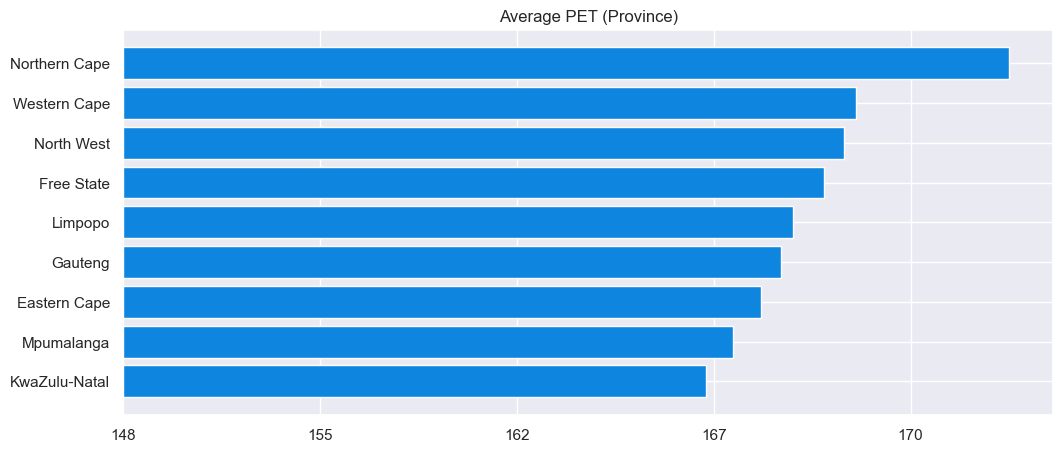

In [11]:
bar_horizontal(piv(gdf, by='pet'), title='Average PET (Province)')

#### Wait...

Call the function again changing the 'y' parameter (```bar_horizontal(piv(gdf, y='pet', by='pet')```). 'y' and 'by' should be equal, so the bar graph will sort the provinces by value of the given parameter. Here are some inputs to choose from:

- 'nir'
- 'green'
- 'swir16'
- 'swir22'
- 'ndmi'
- 'mndwi'
- 'pet'
- 'total alkalinity'
- 'electrical conductance'
- 'dissolved reactive phosphorus'

In [12]:
# Now group by province and aggregate by mean electrical conductance
province_group_EC = piv(df, x='province', y='electrical conductance', by='province')
province_group_TA = piv(df, x='province', y='total alkalinity', by='province')

# Then add aggregated EC data to each provice
provinces = provinces.merge(province_group_EC, on='province')
provinces = provinces.merge(province_group_TA, on='province')
provinces

,id,province,source,geometry,coords,electrical conductance,total alkalinity
0,ZAEC,Eastern Cape,https://simplemaps.com,"POLYGON ((24.14703 -31.78989, 24.15432 -31.758...","(26.577065663967588, -32.09173588687274)",243,104
1,ZAFS,Free State,https://simplemaps.com,"POLYGON ((25.46747 -30.61312, 25.43161 -30.592...","(26.606093829957928, -28.668094454343883)",561,144
2,ZAGP,Gauteng,https://simplemaps.com,"POLYGON ((28.25583 -26.8936, 28.24466 -26.8940...","(28.020037358470212, -26.00964140017083)",622,135
3,ZAKZN,KwaZulu-Natal,https://simplemaps.com,"POLYGON ((30.19597 -31.07789, 30.1925 -31.0729...","(30.414604593508667, -28.941989809339603)",240,71
4,ZALP,Limpopo,https://simplemaps.com,"POLYGON ((31.85649 -23.96296, 31.85623 -23.963...","(29.33324092059666, -23.781743005039885)",475,119
5,ZAMP,Mpumalanga,https://simplemaps.com,"POLYGON ((31.24471 -27.23259, 31.18764 -27.297...","(30.160392842076874, -25.740029807867035)",374,111
6,ZANW,North West,https://simplemaps.com,"POLYGON ((25.01349 -28.06821, 25.00512 -28.070...","(25.243374195623897, -26.37090424293574)",727,186
7,ZANC,Northern Cape,https://simplemaps.com,"POLYGON ((22.63695 -26.11428, 22.70516 -26.129...","(22.022202804943113, -28.846199726745684)",633,149
8,ZAWC,Western Cape,https://simplemaps.com,"MULTIPOLYGON (((17.76711 -31.15581, 17.76742 -...","(22.149666213053404, -32.64267849889474)",494,62


### Total Alkalinity & Electrical Conductance

- Total Alkalinity
    - Resistance to pH fluctuation often measured by buffer concentrations of CaCO3 (or similar titrant) in milligrams per liter or ppm. 
    -  Ideal Range: 20 to 200 mg/L  
- Electrical Conductance
    - How easily electric current flows through a specific object or component, measured in micro-Siemens per centimeter. EC value can tell us the water's ability to conduct an electrical current. The more dissolved ions in the water, the higher the conductivity.
    - Ideal Range: < 800 µS/cm

https://www.usgs.gov/water-science-school/science/alkalinity-and-water  
https://www.boquinstrument.com/a-understanding-the-relationship-between-conductivity-and-water-quality.html


#### **Encodings**

Population Density is encoded using **size**, while water quality parameters (TA and EC) are encoded using **color**. The circular marks' colorscale represent Total Alkalinity (blue) and Electrical Conductance is represented by the color of the outlined provinces (orange).

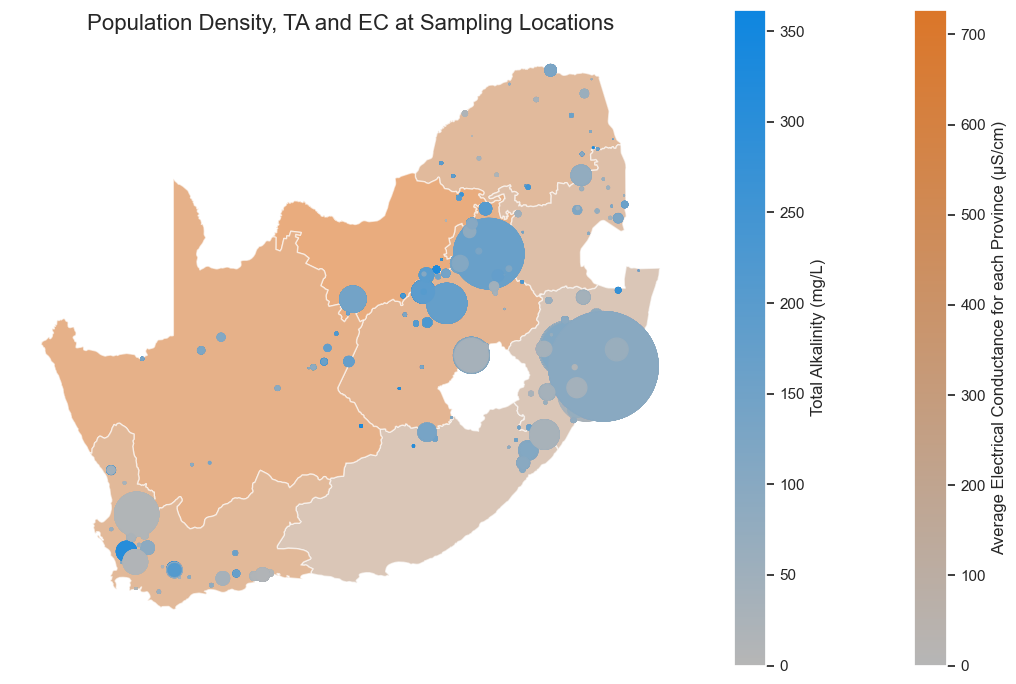

In [13]:
legend_kwds1={'label':'Average Electrical Conductance for each Province (µS/cm)'}
legend_kwds2={'label':'Total Alkalinity (mg/L)'}

spatial_plot_AT_EC(provinces, gdf, plot_unideal=False, legend_kwds1=legend_kwds1, legend_kwds2=legend_kwds2)

#### **Observation and Analysis**

Like PET, EC is higher in the west than in the east. Total Alkalinity values are depicted slightly lower in the south than the north. Same as the observation above about PET, I think water quality is fluctuating according to the climactic factors represented in the Google Maps snapshot of South Africa above.
Higher EC typically means there is a higher concentration of dissolved substances. It is not clear from the raw measurement of EC, whether those dissolved substances are beneficial or not. It purely represents the concentrations of ions in water. That being said, drinking water with excessively high levels of certain ions can lead to health risks.

Alkalinity on the other hand describes a water sample sources buffering capacity. The presence of buffers in water help maintain stable pH levels, which is essential for aquatic life. Buffers are chemical compounds, like bicarbonates, carbonates and hydroxides that can react with acids or bases to keep the pH in a particular range. Basically, if a body of water has stable pH, it is a good indicator of the water's quality. There is actually no upper or lower limit for alkalinity in drinking water, but the recommended pH lies between 6.5 - 8.5.

One interesting thing to point out is population density doesn't seem to affect these water quality measurements. There are large circle marks with low values and vice versa.

#### It looks like Total Alkalinity and Electrical Conductance have a moderate positive correlation

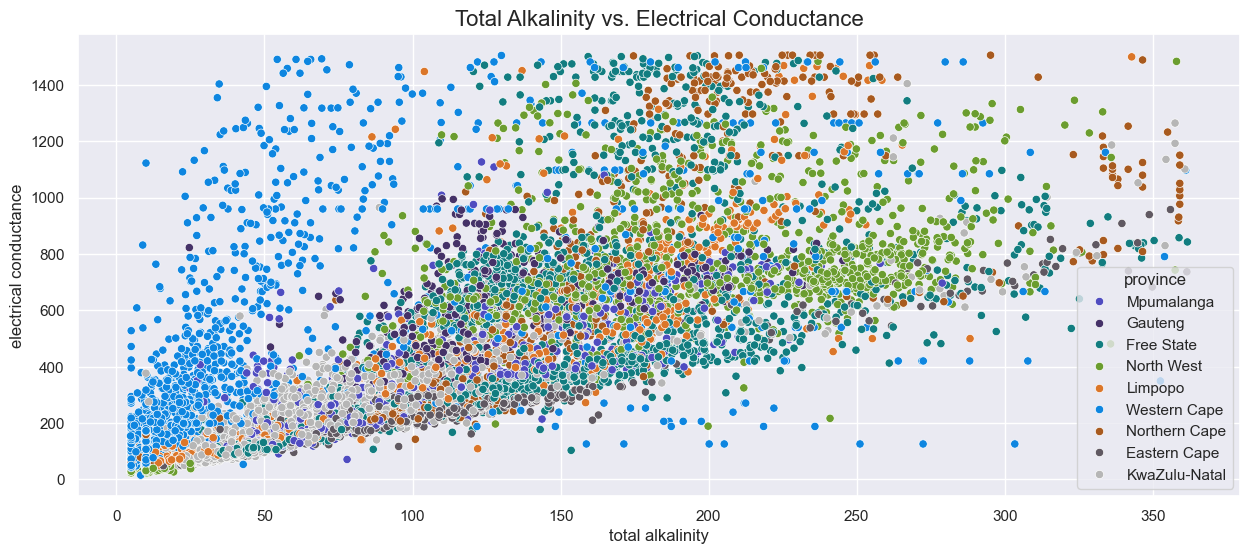

In [14]:
colors = ['#4F4CC0','#453268','#127D80','#6B9D2F','#DB7629','#0E86E0','#A85A1F','#605962','#B6B6B6']

fig, ax = plt.subplots(figsize=(15, 6))
sns.scatterplot(data=gdf, x="total alkalinity", y="electrical conductance", hue='province', palette=colors)
plt.title("Total Alkalinity vs. Electrical Conductance", fontsize=16);

**Description: as the buffering capacity of water increases, the concentration of dissolved ions in that water also increases. Here we observe a direct relationship between TA and EC.**

### How are our parameters related to time??

- LET's GO FOR SPEED!!!
- Here we can explore ways to analyze PET, and other water quality parameters if we want.

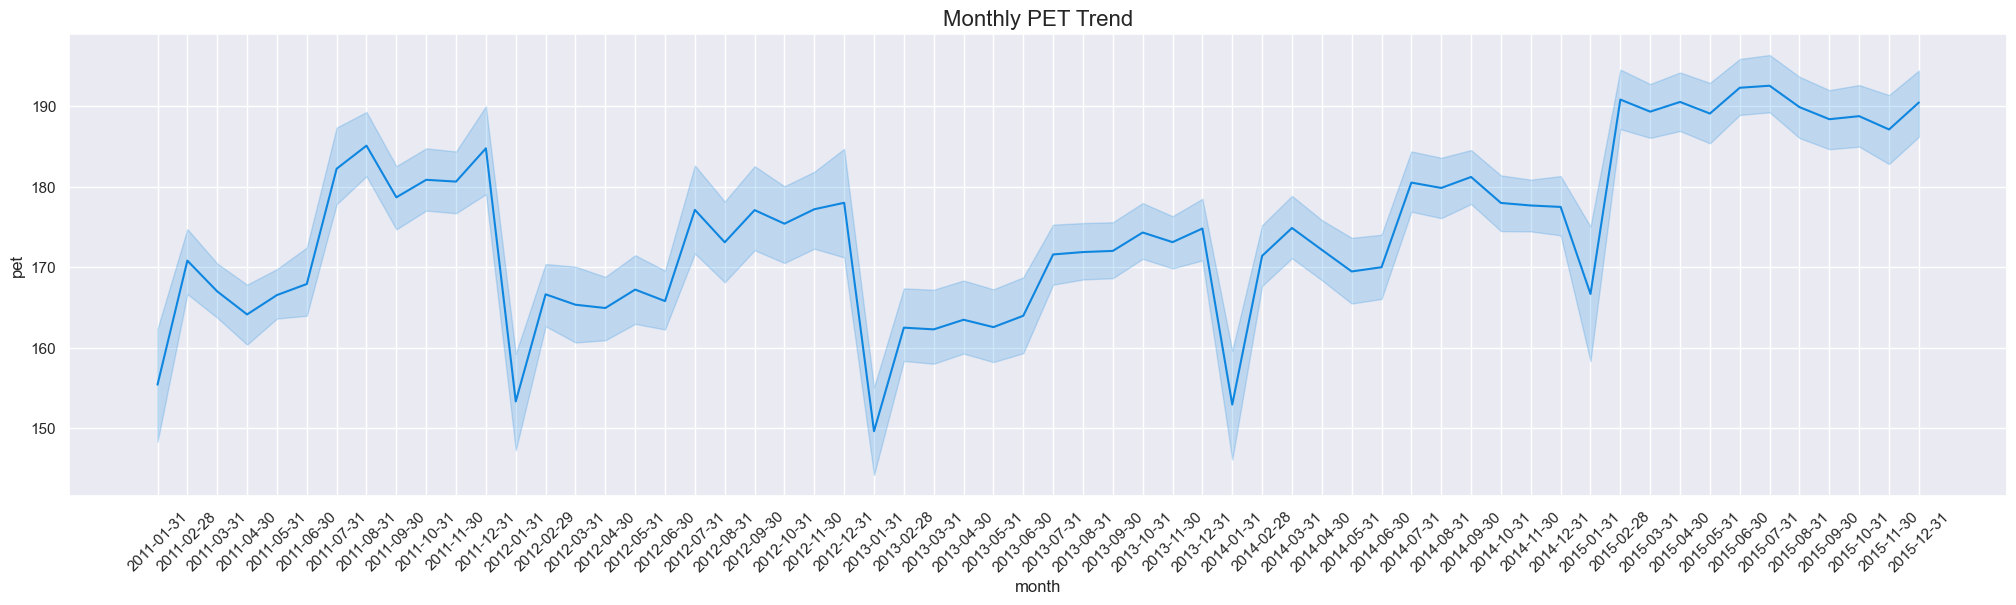

In [15]:
# Monthly time series vs PET (make sure to sort values by month)*
gdf = gdf.sort_values(by='month')

fig, ax = plt.subplots(figsize=(25, 6));
sns.lineplot(data=gdf, x="month", y="pet", color=colors[5])
plt.xticks(rotation=45)
plt.title('Monthly PET Trend', fontsize=16);

**Earlier I mentioned PET depends on temperature. Here we can see the temperature is dropping every December (the beginning of summer in the southern hemisphere), except for in 2015, which is the last year we have access to. We need more data beyond 2015 to see whether this temperature-related-trend continued.**

#### There are 5 distinct periods where PET drops unordinarily low, relative to the rest of the data.

But if PET is related to temperature as possibly observed in the previous plot, this would make sense, because the values are dropping during the same months, systemically.

NOTE: This is the same data as visualized above. However, in a scatterplot, the data are binned.

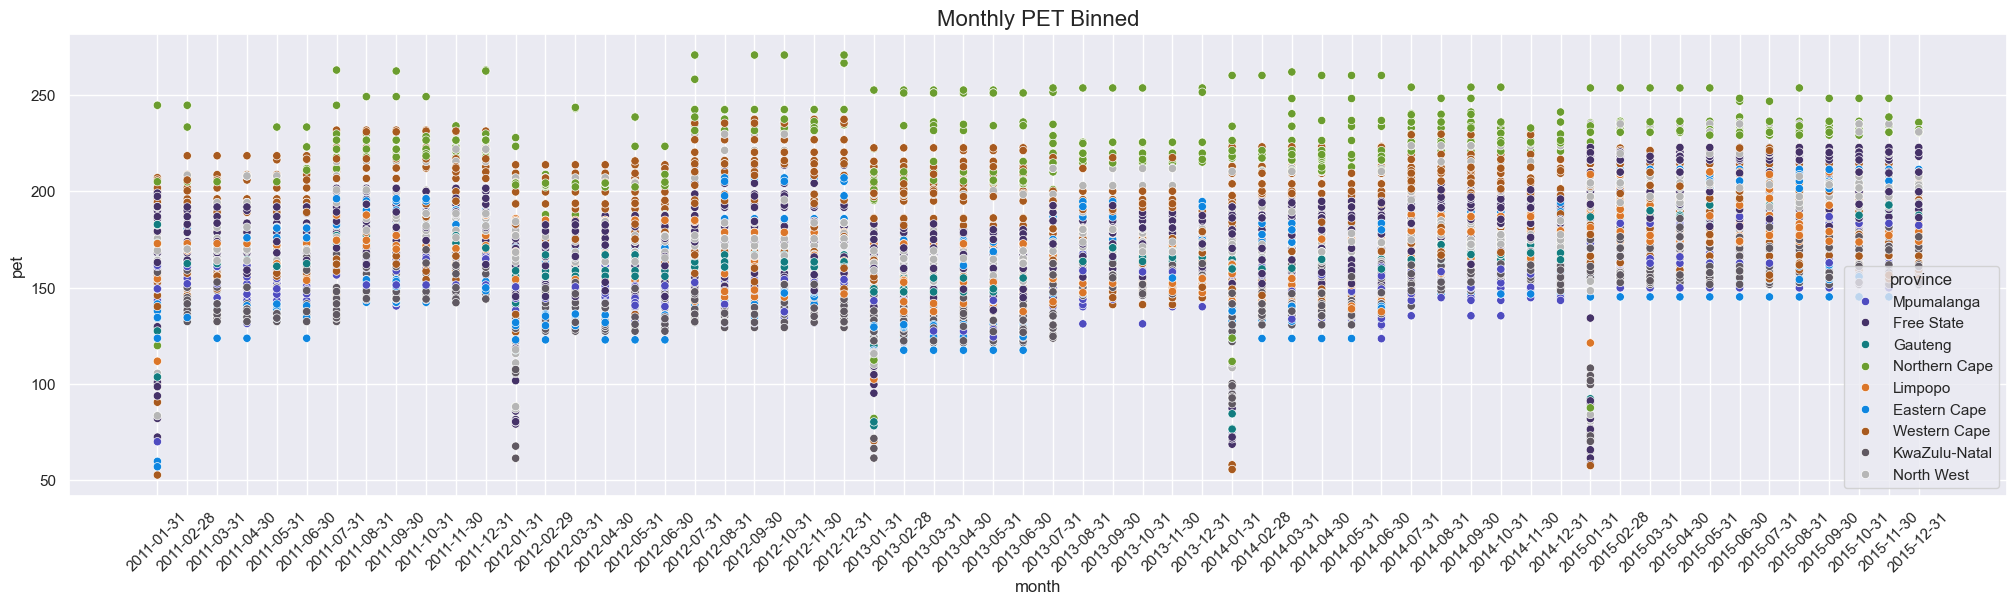

In [16]:
fig, ax = plt.subplots(figsize=(25, 6));
sns.scatterplot(data=gdf, x="month", y="pet", hue='province', palette=colors)
plt.xticks(rotation=45)
plt.title('Monthly PET Binned', fontsize=16);

#### **Let us pivot**

Interestingly, the values of each parameter are falling around the same period (~Novemer of each year). South Africa is in the Southern Hemisphere, which has opposite seasons than many are used to, north of the equator.

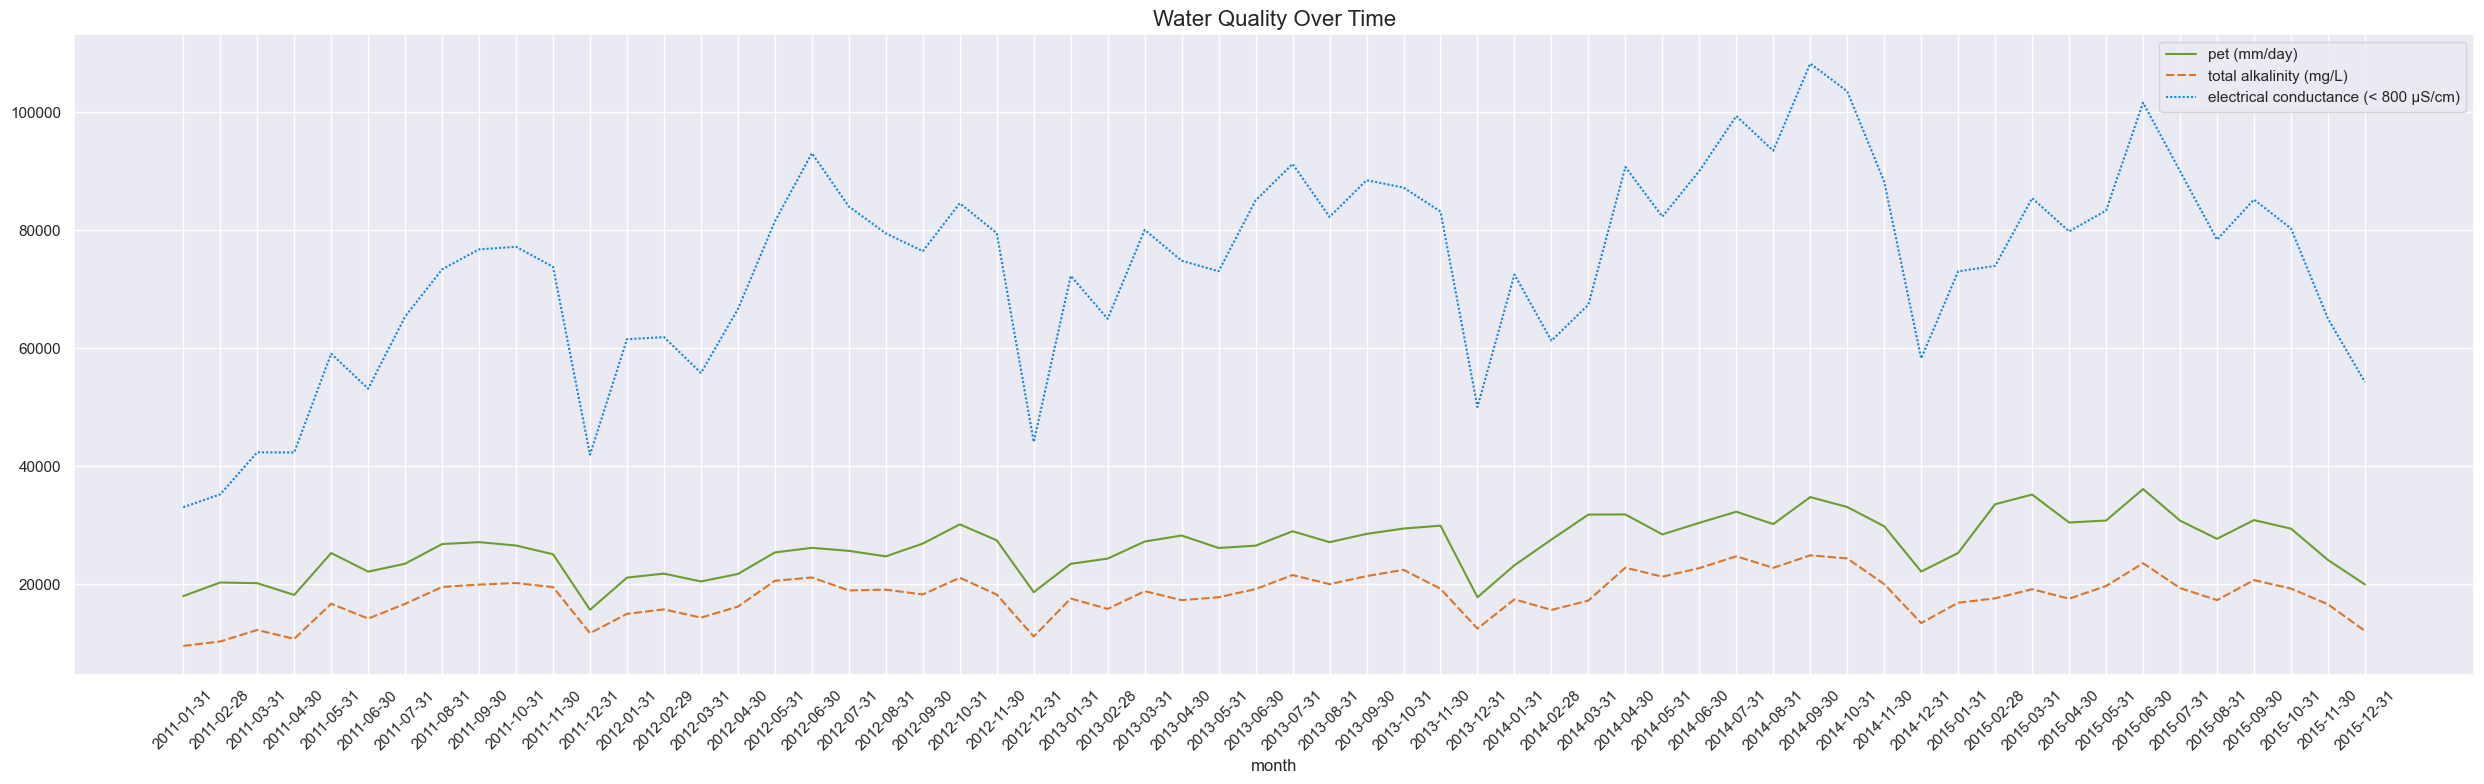

In [17]:
# create alternative time series data to plot (GROUPBY MONTH; AGGREGATE by SUM)
pivot_table1 = gdf[['pet', 'total alkalinity', 'electrical conductance', 'month']].groupby('month').sum().astype(int)
pivot_table2 = gdf[['nir', 'green','swir16', 'swir22', 'month']].groupby('month').sum().astype(int)
pivot_table3 = gdf[['nir', 'green','swir16', 'swir22', 'pet', 'total alkalinity', 'electrical conductance', 'month']].groupby('month').sum().astype(int)
pivot_table3 = gdf[['ndmi', 'mndwi', 'month']].groupby('month').sum().astype(int)

# add units for clarity: mm/day, TA: mg/L, EC: < 800 µS/cm
pivot_table1.columns = ['pet (mm/day)', 'total alkalinity (mg/L)', 'electrical conductance (< 800 µS/cm)']

fig, ax = plt.subplots(figsize=(25, 8))

sns.lineplot(data=pivot_table1, palette=[colors[3],colors[4],colors[5]])

plt.xticks(rotation=45)
plt.title('Water Quality Over Time', fontsize=16)
plt.tight_layout()
plt.show();

# dual yaxis => leads to a lot of clutter when trying to visualize more than 2 variables

### **Correlation Matrix**

I decided to just throw all variables possible into a correlation matrix for final observations.

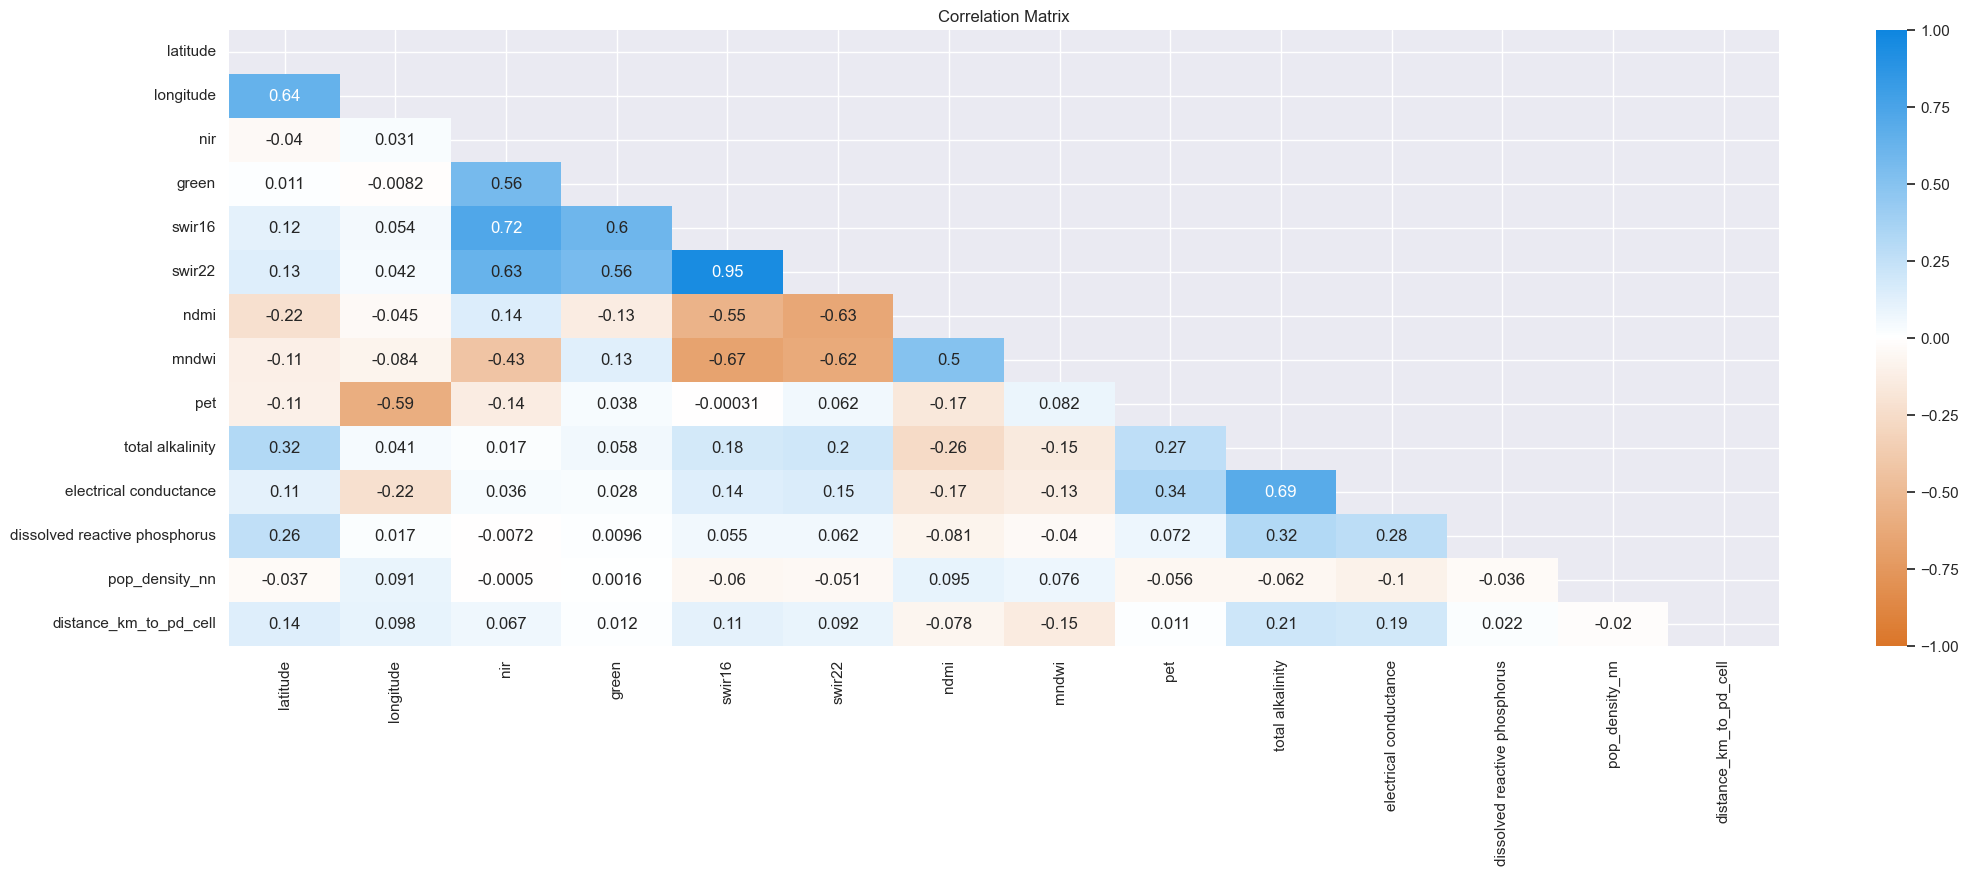

In [18]:
# Observing patterns of correlation is easier when plotted

# Select only numnerical columns
corr = df.select_dtypes(include=float).corr()

# Set colors
cmap = LinearSegmentedColormap.from_list("mycmap", ['#DB7629', '#FFFFFF', '#0E86E0'])

# Create a mask using numpy's triu function
# https://www.datacamp.com/tutorial/seaborn-heatmaps
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(25, 8))
sns.heatmap(corr, cmap=cmap, vmin=-1, vmax=1, center=0, annot=True, mask=mask)

plt.title('Correlation Matrix');

#### Observation and Analysis

There are generally no strong correlations. The satellite data (nir, green, swir16, swir22, ndmi, mndwi) have the strongest correlation among each other, suggesting they could have an effect on one another. Total alkalinity and Electrical have a realtively strong correlation. The strongest correlation in the dataset. We believe they are measuring similar parameters.

There is also some geografical correlation, for example, PET is negatively correlated with longitude while total alkalinity and DRP have a slightly positive correlation with latitude. 
- PET values are generally increasing from East to West.
- If you refer back to the map visualization above, you'll notice the encoded range of values for total alkalinity change ever so slightly when observing the data points' color from south to north.

#### **Conclusion:**

In conclusion, we don't have enough key features to determine water quality. Ideally, we would need to find sources of information that would accompany our data with pH level and water temperature for linear period starting at the end of 2015.